In [1]:
from nbody.bodies import *
from nbody.constants import *
from nbody.integrators import *
from nbody.validation import *
from nbody.visualization import *

In [2]:
N = int(input("Number of bodies: "))
print("N =", N)

if (N > 10) or (N < 2):
  raise ValueError("Number of bodies must be between 2 and 10.")

if N == 2:
  option = int(input("Method: 0 = Kepler (2-Body), 1 = Semi-Implicit Euler, 2 = Velocity Verlet, 3 = RK4: "))
else:
  option = int(input("Method: 1 = Semi-Implicit Euler, 2 = Velocity Verlet, 3 = RK4: "))

if option not in METHODS:
  raise ValueError("Invalid method")

print("Selected method:", METHODS[option])

N = 4
Selected method: Velocity Verlet


In [3]:
bodies = generate_bodies(option, N)

Body 1: mass: 1.121192, pos: [0.673408 -0.066318], vel: [-0.063937 0.499108], acc: [0.000000 0.000000]
Body 2: mass: 1.690893, pos: [0.927133 0.184008], vel: [0.371772 -0.508323], acc: [0.000000 0.000000]
Body 3: mass: 0.616983, pos: [0.743371 0.557140], vel: [-0.518861 -0.797960], acc: [0.000000 0.000000]
Body 4: mass: 1.299174, pos: [0.095478 0.976422], vel: [-0.182280 0.609812], acc: [0.000000 0.000000]


In [4]:
x = [[body.position[0]] for body in bodies]
y = [[body.position[1]] for body in bodies]

total_energy, total_linear, total_angular = [], [], []
abs_energy,   abs_linear,   abs_angular   = [], [], []
rel_energy,   rel_linear,   rel_angular   = [], [], []

E0 = energy(bodies, option)
P0 = linear_momentum(bodies)
L0 = angular_momentum(bodies)

In [5]:
runners = {
    0: run_kepler,
    1: run_euler,
    2: run_verlet,
    3: run_rk4
}

runners[option](
    steps, dt, bodies,
    x, y, E0, P0, L0,
    total_energy, total_linear, total_angular,
    abs_energy, abs_linear, abs_angular,
    rel_energy, rel_linear, rel_angular
)

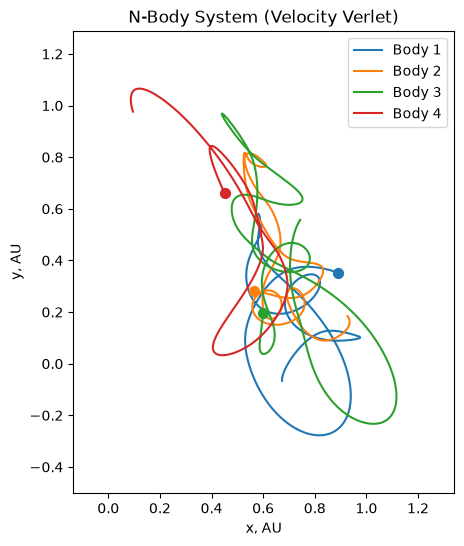

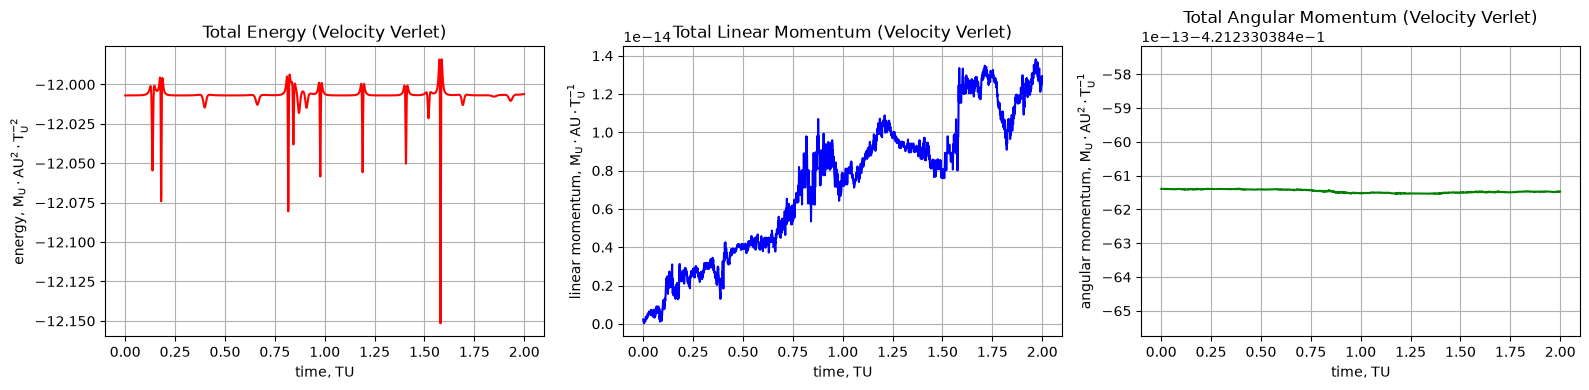

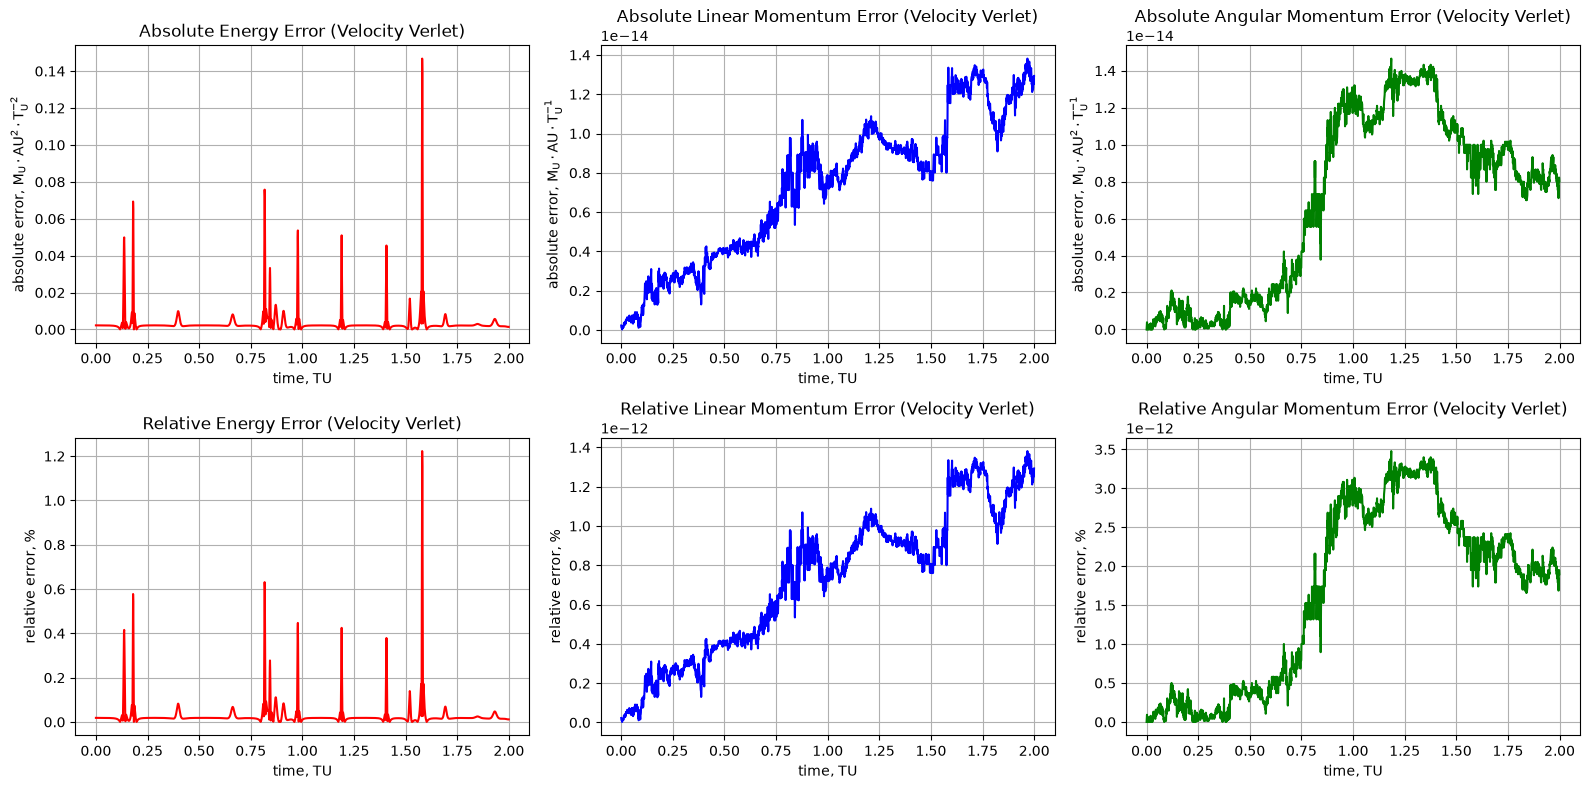

In [6]:
plot_trajectories(bodies, x, y, option, save_path="trajectories.pdf")
plot_conserved_quantities(total_energy, total_linear, total_angular, option, dt)
plot_errors(abs_energy, abs_linear, abs_angular,
            rel_energy, rel_linear, rel_angular, option, dt)